# Teste end-to-end — Emoções por Texto + Prosódia + Late Fusion

Este notebook serve para testar a pipeline final do projeto:

1. **Áudio** (`.wav`, `.mp3`, `.m4a`, `.flac`, `.ogg`)  
2. **Transcrição automática** com `openai/whisper-large-v3-turbo`  
3. **Classificação textual** com `qwen2.5:3b-instruct` via Ollama, estratégia `Advanced_V2`  
4. **Classificação prosódica** com o modelo `SVM_RBF` treinado no notebook de prosódia  
5. **Late fusion ponderada/adaptativa** para gerar uma distribuição final pelas 7 emoções

Classes usadas:

```text
joy, sadness, surprise, anger, disgust, fear, neutral
```

> Coloca este notebook, o ficheiro `prosody_final_pipeline.joblib` e os teus áudios na mesma pasta.  
> O notebook também procura áudios dentro de uma pasta chamada `audios_teste/`, caso a cries.

## 0. Nomes recomendados para os ficheiros áudio

Grava um ficheiro por emoção. O notebook reconhece estes nomes:

| Ficheiro recomendado | Emoção esperada |
|---|---|
| `joy.wav` | joy / feliz |
| `sad.wav` ou `sadness.wav` | sadness / triste |
| `surprise.wav` | surprise / surpresa |
| `anger.wav` | anger / raiva |
| `disgust.wav` | disgust / nojo/repulsa |
| `fear.wav` | fear / medo |
| `neutral.wav` | neutral / neutro |

Os áudios devem ter idealmente **30–60 segundos** e ser gravados em português.

## 1. Instalação de dependências

Corre esta célula se estiveres num ambiente novo. Se já tiveres tudo instalado, podes saltar.

**Nota:** o Whisper large-v3-turbo pode demorar a descarregar na primeira execução.

In [21]:
# Descomenta se precisares de instalar dependências
# !pip install -q transformers accelerate torch librosa soundfile scikit-learn joblib pandas numpy matplotlib requests tqdm praat-parselmouth

## 2. Configuração global

Antes de correr:

1. Confirma que tens o Ollama aberto:

```bash
ollama serve
```

2. Confirma que tens o modelo textual:

```bash
ollama pull qwen2.5:3b-instruct
```

3. Coloca o modelo da prosódia `prosody_final_pipeline.joblib` na mesma pasta deste notebook.

In [22]:
import os
import re
import json
import math
import time
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import requests
import joblib
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

try:
    import torch
    from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor, pipeline
    TRANSFORMERS_AVAILABLE = True
except Exception as e:
    TRANSFORMERS_AVAILABLE = False
    print("⚠️ Transformers/Torch não disponíveis:", e)

try:
    import parselmouth
    from parselmouth.praat import call
    PARSELMOUTH_AVAILABLE = True
except Exception:
    PARSELMOUTH_AVAILABLE = False

# Emoções finais do projeto
EMOTIONS = ["joy", "sadness", "surprise", "anger", "disgust", "fear", "neutral"]

# Modelos finais selecionados nos notebooks anteriores
TEXT_MODEL = "qwen2.5:3b-instruct"
WHISPER_MODEL_ID = "openai/whisper-large-v3-turbo"
PROSODY_MODEL_PATH = Path("prosody_final_pipeline.joblib")

# Pasta onde vais colocar os áudios.
# Se audios_teste/ existir, o notebook usa essa pasta; caso contrário, usa a pasta atual.
AUDIO_DIR = Path("audios_teste") if Path("audios_teste").exists() else Path(".")
OUTPUT_DIR = Path("multimodal_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Transcrição: para português, usar task="transcribe".
# task="translate" traduziria para inglês, o que NÃO é o recomendado aqui.
ASR_TASK = "transcribe"
ASR_LANGUAGE = "portuguese"

# Pesos base da fusão final.
# Como o texto teve F1-Macro ~0.788 e a prosódia ~0.408 LOSO-CV, o texto deve ter mais peso.
BASE_TEXT_WEIGHT = 0.75
BASE_AUDIO_WEIGHT = 0.25
ADAPTIVE_FUSION = True

TARGET_SR = 16000
TRIM_SILENCE = True
TOP_DB = 25
MIN_SECONDS = 0.25

print(f"✅ Parselmouth disponível: {PARSELMOUTH_AVAILABLE}")
print(f"✅ Pasta de áudio: {AUDIO_DIR.resolve()}")
print(f"✅ Pasta de outputs: {OUTPUT_DIR.resolve()}")
print(f"✅ Modelo Whisper: {WHISPER_MODEL_ID}")
print(f"✅ Modelo textual Ollama: {TEXT_MODEL}")
print(f"✅ Modelo prosódico esperado: {PROSODY_MODEL_PATH.resolve()}")

✅ Parselmouth disponível: True
✅ Pasta de áudio: /home/tomas/MIA/1ANO/2SEM/CA/CA-25_26/tests/final
✅ Pasta de outputs: /home/tomas/MIA/1ANO/2SEM/CA/CA-25_26/tests/final/multimodal_outputs
✅ Modelo Whisper: openai/whisper-large-v3-turbo
✅ Modelo textual Ollama: qwen2.5:3b-instruct
✅ Modelo prosódico esperado: /home/tomas/MIA/1ANO/2SEM/CA/CA-25_26/tests/final/prosody_final_pipeline.joblib


## 3. Descobrir áudios na pasta

Esta célula procura ficheiros de áudio na pasta atual ou em `audios_teste/`.

In [23]:
AUDIO_EXTENSIONS = {".wav", ".mp3", ".m4a", ".flac", ".ogg", ".aac"}

FILENAME_TO_EXPECTED = {
    "joy": "joy",
    "happy": "joy",
    "feliz": "joy",
    "sad": "sadness",
    "sadness": "sadness",
    "triste": "sadness",
    "surprise": "surprise",
    "surprised": "surprise",
    "surpresa": "surprise",
    "anger": "anger",
    "angry": "anger",
    "raiva": "anger",
    "zangado": "anger",
    "disgust": "disgust",
    "nojo": "disgust",
    "repulsa": "disgust",
    "fear": "fear",
    "medo": "fear",
    "neutral": "neutral",
    "neutro": "neutral",
}

def expected_from_filename(path: Path) -> Optional[str]:
    stem = path.stem.lower().strip()
    # match direto
    if stem in FILENAME_TO_EXPECTED:
        return FILENAME_TO_EXPECTED[stem]
    # match parcial, por exemplo audio_joy_01.wav
    for key, label in FILENAME_TO_EXPECTED.items():
        if re.search(rf"(^|[_\-\s]){re.escape(key)}($|[_\-\s])", stem):
            return label
    return None


def discover_audio_files(audio_dir: Path = AUDIO_DIR) -> List[Path]:
    files = []
    for p in sorted(audio_dir.iterdir()):
        if p.is_file() and p.suffix.lower() in AUDIO_EXTENSIONS:
            files.append(p)
    return files

AUDIO_FILES = discover_audio_files(AUDIO_DIR)

if not AUDIO_FILES:
    print("⚠️ Ainda não encontrei áudios.")
    print("Coloca ficheiros como joy.wav, sad.wav, anger.wav, etc., na pasta:")
    print(AUDIO_DIR.resolve())
else:
    rows = []
    for p in AUDIO_FILES:
        rows.append({"file": p.name, "expected_from_name": expected_from_filename(p), "path": str(p)})
    display(pd.DataFrame(rows))

,file,expected_from_name,path
0,anger.wav,anger,anger.wav
1,disgust.wav,disgust,disgust.wav
2,fear.wav,fear,fear.wav
3,joy.wav,joy,joy.wav
4,neutral.wav,neutral,neutral.wav
5,sad.wav,sadness,sad.wav
6,surprise.wav,surprise,surprise.wav


## 4. Carregar Whisper large-v3-turbo

Esta célula carrega o modelo `openai/whisper-large-v3-turbo` através da biblioteca `transformers`.

- Em GPU, deve usar `float16`.
- Em CPU, funciona, mas pode ser lento.

In [24]:
asr_pipe = None

def load_whisper_pipeline(model_id: str = WHISPER_MODEL_ID):
    if not TRANSFORMERS_AVAILABLE:
        raise RuntimeError("Transformers/Torch não estão disponíveis. Instala com: pip install transformers accelerate torch")

    device = "cuda:0" if torch.cuda.is_available() else "cpu"
    torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32
    device_arg = 0 if torch.cuda.is_available() else -1

    print(f"A carregar Whisper em {device} com dtype={torch_dtype}...")
    model = AutoModelForSpeechSeq2Seq.from_pretrained(
        model_id,
        torch_dtype=torch_dtype,
        low_cpu_mem_usage=True,
        use_safetensors=True,
    )
    model.to(device)
    processor = AutoProcessor.from_pretrained(model_id)

    pipe = pipeline(
        "automatic-speech-recognition",
        model=model,
        tokenizer=processor.tokenizer,
        feature_extractor=processor.feature_extractor,
        torch_dtype=torch_dtype,
        device=device_arg,
        chunk_length_s=30,
        batch_size=8,
    )
    return pipe

# Carrega só uma vez
asr_pipe = load_whisper_pipeline()
print("✅ Whisper pronto.")

A carregar Whisper em cpu com dtype=torch.float32...


Loading weights: 100%|██████████| 587/587 [00:01<00:00, 486.55it/s]
[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


✅ Whisper pronto.


In [25]:
def transcribe_audio(audio_path: Path) -> str:
    if asr_pipe is None:
        raise RuntimeError("O pipeline Whisper ainda não foi carregado. Corre a célula anterior.")

    result = asr_pipe(
        str(audio_path),
        generate_kwargs={"language": ASR_LANGUAGE, "task": ASR_TASK},
    )
    text = result.get("text", "") if isinstance(result, dict) else str(result)
    return text.strip()

# Teste rápido opcional: transcrever apenas o primeiro áudio encontrado
if AUDIO_FILES:
    print("Áudio:", AUDIO_FILES[0].name)
    print(transcribe_audio(AUDIO_FILES[0]))

Áudio: anger.wav


Driver does not support the 0x46a3 PCI ID.
libGL error: failed to create dri screen
libGL error: failed to load driver: iris


Hoje fiquei bastante irritado. Houve uma situação em que senti que fui tratado de forma injusta e isso estragou-me o resto do dia. Tentei manter a calma, mas quanto mais pensava no assunto, mais frustrado ficava. Senti que o meu esforço não foi respeitado e isso deixou-me revoltado. No fim do dia, ainda estava a tentar acalmar-me e esquecer o que aconteceu.


## 5. Classificador textual — Qwen Advanced_V2 via Ollama

Esta secção implementa a estratégia textual final usada no notebook do texto:

- Modelo: `qwen2.5:3b-instruct`
- Estratégia: `Advanced_V2`
- Saída: distribuição probabilística pelas 7 emoções

In [26]:
def check_ollama(model_name: str = TEXT_MODEL, base_url: str = "http://localhost:11434") -> bool:
    try:
        r = requests.get(f"{base_url}/api/tags", timeout=5)
        r.raise_for_status()
        models = r.json().get("models", [])
        names = [m.get("name", "") for m in models]
        ok = any(model_name in name for name in names)
        if not ok:
            print(f"⚠️ Ollama está ligado, mas não encontrei {model_name}.")
            print(f"Modelos disponíveis: {names}")
            print(f"Corre: ollama pull {model_name}")
        return ok
    except Exception as e:
        print("❌ Não consegui contactar o Ollama em http://localhost:11434")
        print("Confirma se está a correr: ollama serve")
        print("Erro:", e)
        return False

check_ollama()

True

In [27]:
def normalize_distribution(dist: Dict[str, float], emotions: List[str] = EMOTIONS) -> Dict[str, float]:
    clean = {}
    for emo in emotions:
        try:
            v = float(dist.get(emo, 0.0))
        except Exception:
            v = 0.0
        clean[emo] = max(0.0, v)

    total = sum(clean.values())
    if total <= 0:
        # fallback conservador
        clean = {emo: 0.0 for emo in emotions}
        clean["neutral"] = 1.0
        return clean

    return {emo: clean[emo] / total for emo in emotions}


def parse_distribution_from_text(raw: str, emotions: List[str] = EMOTIONS) -> Dict[str, float]:
    raw = raw.strip()

    # Tenta encontrar JSON no texto
    match = re.search(r"\{.*\}", raw, flags=re.DOTALL)
    if match:
        try:
            data = json.loads(match.group(0))
            return normalize_distribution(data, emotions)
        except Exception:
            pass

    # Fallback se o modelo responder só com uma label
    aliases = {
        "alegria": "joy", "feliz": "joy", "joy": "joy",
        "tristeza": "sadness", "triste": "sadness", "sadness": "sadness",
        "surpresa": "surprise", "surprise": "surprise",
        "raiva": "anger", "zangado": "anger", "anger": "anger",
        "nojo": "disgust", "repulsa": "disgust", "disgust": "disgust",
        "medo": "fear", "fear": "fear",
        "neutro": "neutral", "neutral": "neutral",
    }
    low = raw.lower()
    for key, emo in aliases.items():
        if key in low:
            out = {e: 0.02 for e in emotions}
            out[emo] = 0.88
            return normalize_distribution(out, emotions)

    out = {emo: 0.0 for emo in emotions}
    out["neutral"] = 1.0
    return out


def call_ollama(prompt: str, model_name: str = TEXT_MODEL, temperature: float = 0.1, timeout: int = 180) -> str:
    payload = {
        "model": model_name,
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": temperature,
            "top_p": 0.9,
            "num_ctx": 4096,
        },
    }
    r = requests.post("http://localhost:11434/api/generate", json=payload, timeout=timeout)
    r.raise_for_status()
    return r.json().get("response", "")

In [28]:
FEW_SHOT_EXAMPLES = [
    ("Hoje acordei cheio de energia, recebi uma boa notícia e passei o dia com uma sensação de gratidão e entusiasmo.", "joy"),
    ("Consegui terminar uma tarefa importante e senti orgulho no meu esforço. Foi um dia leve e positivo.", "joy"),
    ("Hoje senti um peso enorme. Tive vontade de chorar e pareceu que nada do que fiz tinha grande sentido.", "sadness"),
    ("Passei o dia desanimado, com saudades e com uma sensação de vazio difícil de explicar.", "sadness"),
    ("Recebi uma notícia completamente inesperada e fiquei sem reação durante alguns minutos.", "surprise"),
    ("O dia parecia normal, mas aconteceu algo que me apanhou totalmente desprevenido e fiquei espantado.", "surprise"),
    ("Fiquei irritado porque senti que fui tratado de forma injusta e passei o dia a tentar conter a frustração.", "anger"),
    ("Uma situação no trabalho deixou-me revoltado. Senti raiva e dificuldade em acalmar-me.", "anger"),
    ("Vi uma atitude que me causou repulsa e fiquei incomodado durante o resto do dia.", "disgust"),
    ("Houve uma situação tão desagradável que me deixou com nojo e vontade de me afastar.", "disgust"),
    ("Passei o dia ansioso, com medo de que alguma coisa corresse mal e sem conseguir relaxar.", "fear"),
    ("Senti insegurança e preocupação constante, como se houvesse uma ameaça à minha volta.", "fear"),
    ("Hoje foi um dia normal. Fiz as minhas tarefas, almocei, trabalhei e descansei um pouco ao fim da tarde.", "neutral"),
    ("O dia correu dentro da rotina, sem acontecimentos marcantes nem emoções fortes.", "neutral"),
]


def label_distribution(label: str, high: float = 0.86) -> Dict[str, float]:
    low = (1.0 - high) / (len(EMOTIONS) - 1)
    return {emo: (high if emo == label else low) for emo in EMOTIONS}


def few_shot_block() -> str:
    blocks = []
    for text, label in FEW_SHOT_EXAMPLES:
        blocks.append(
            "Texto: " + text + "\n" +
            "JSON: " + json.dumps(label_distribution(label), ensure_ascii=False)
        )
    return "\n\n".join(blocks)


def query_advanced_v2(text: str, model_name: str = TEXT_MODEL) -> Dict[str, float]:
    prompt = f"""
És um classificador de emoções para relatos diários em português europeu.

Objetivo: devolver uma distribuição probabilística pelas 7 classes:
{', '.join(EMOTIONS)}.

Critérios principais:
- joy: alegria, satisfação, entusiasmo, orgulho, alívio positivo.
- sadness: perda, vazio, desânimo, choro, sofrimento emocional.
- surprise: acontecimento inesperado, choque, espanto, reação de incredulidade.
- anger: injustiça, frustração, irritação, revolta, traição.
- disgust: nojo, repulsa, desprezo moral ou físico.
- fear: ameaça, ansiedade intensa, insegurança, perigo, pânico.
- neutral: rotina, relato factual, ausência de emoção dominante.

Distingue especialmente:
- fear vs surprise: fear envolve ameaça/ansiedade; surprise envolve inesperado/espanto.
- anger vs disgust: anger envolve revolta/frustração; disgust envolve repulsa/nojo.
- sadness vs neutral: sadness tem sofrimento/perda; neutral é factual/rotineiro.

Exemplos:
{few_shot_block()}

Agora classifica o texto seguinte.
Responde apenas com JSON válido, sem explicações.
O JSON deve conter exatamente estas chaves: {', '.join(EMOTIONS)}.

Texto:
{text}

JSON:
""".strip()
    raw = call_ollama(prompt, model_name=model_name, temperature=0.1)
    return parse_distribution_from_text(raw)


def classify_text_emotion(text: str) -> Dict[str, float]:
    return query_advanced_v2(text, model_name=TEXT_MODEL)

# Teste rápido opcional
print(classify_text_emotion("Hoje foi um dia excelente, senti-me feliz e orgulhoso do que consegui fazer."))

{'joy': 0.9866666666666667, 'sadness': 0.013333333333333332, 'surprise': 0.0, 'anger': 0.0, 'disgust': 0.0, 'fear': 0.0, 'neutral': 0.0}


## 6. Classificador prosódico — SVM_RBF

Esta secção carrega o `prosody_final_pipeline.joblib` gerado pelo notebook de prosódia.

O ficheiro deve estar na mesma pasta deste notebook.

In [29]:
def load_prosody_artifact(path: Path = PROSODY_MODEL_PATH):
    if not path.exists():
        raise FileNotFoundError(
            f"Não encontrei {path.resolve()}\n"
            "Coloca o ficheiro prosody_final_pipeline.joblib na mesma pasta deste notebook."
        )
    artifact = joblib.load(path)
    if isinstance(artifact, dict):
        pipe = artifact.get("pipeline")
        feature_columns = artifact.get("feature_columns")
        emotions = artifact.get("emotions", EMOTIONS)
        model_name = artifact.get("model_name", "prosody_model")
    else:
        pipe = artifact
        feature_columns = getattr(pipe, "feature_names_in_", None)
        emotions = EMOTIONS
        model_name = "prosody_model"

    if pipe is None:
        raise ValueError("O artefacto não contém uma pipeline válida.")
    if feature_columns is None:
        raise ValueError("Não consegui encontrar feature_columns no artefacto.")
    return pipe, list(feature_columns), list(emotions), model_name

prosody_pipeline, PROSODY_FEATURE_COLUMNS, PROSODY_EMOTIONS, PROSODY_MODEL_NAME = load_prosody_artifact()
print(f"✅ Modelo prosódico carregado: {PROSODY_MODEL_NAME}")
print(f"✅ Nº de features esperadas: {len(PROSODY_FEATURE_COLUMNS)}")
print(f"✅ Emoções no modelo: {PROSODY_EMOTIONS}")

✅ Modelo prosódico carregado: SVM_RBF
✅ Nº de features esperadas: 109
✅ Emoções no modelo: ['joy', 'sadness', 'surprise', 'anger', 'disgust', 'fear', 'neutral']


In [30]:
def load_audio(path: Path, target_sr: int = TARGET_SR) -> Tuple[np.ndarray, int]:
    y, sr = librosa.load(path, sr=target_sr, mono=True)
    y = np.asarray(y, dtype=np.float32)
    if TRIM_SILENCE and len(y) > 0:
        y, _ = librosa.effects.trim(y, top_db=TOP_DB)
    min_len = int(MIN_SECONDS * target_sr)
    if len(y) < min_len:
        y = np.pad(y, (0, max(0, min_len - len(y))))
    return y, target_sr


def _safe_stats(prefix: str, values: np.ndarray) -> Dict[str, float]:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return {
            f"{prefix}_mean": np.nan,
            f"{prefix}_std": np.nan,
            f"{prefix}_min": np.nan,
            f"{prefix}_max": np.nan,
            f"{prefix}_median": np.nan,
            f"{prefix}_range": np.nan,
        }
    return {
        f"{prefix}_mean": float(np.mean(values)),
        f"{prefix}_std": float(np.std(values)),
        f"{prefix}_min": float(np.min(values)),
        f"{prefix}_max": float(np.max(values)),
        f"{prefix}_median": float(np.median(values)),
        f"{prefix}_range": float(np.max(values) - np.min(values)),
    }


def extract_parselmouth_features(y: np.ndarray, sr: int) -> Dict[str, float]:
    if not PARSELMOUTH_AVAILABLE:
        return {"jitter_local": np.nan, "shimmer_local": np.nan, "hnr_mean": np.nan}
    try:
        snd = parselmouth.Sound(y, sampling_frequency=sr)
        fmin, fmax = 50, 500
        point_process = call(snd, "To PointProcess (periodic, cc)", fmin, fmax)
        jitter = call(point_process, "Get jitter (local)", 0, 0, 1 / fmax, 1 / fmin, 1.3)
        shimmer = call([snd, point_process], "Get shimmer (local)", 0, 0, 1 / fmax, 1 / fmin, 1.3, 1.6)
        harmonicity = call(snd, "To Harmonicity (cc)", 0.01, fmin, 0.1, 1.0)
        hnr = call(harmonicity, "Get mean", 0, 0)
        return {"jitter_local": float(jitter), "shimmer_local": float(shimmer), "hnr_mean": float(hnr)}
    except Exception:
        return {"jitter_local": np.nan, "shimmer_local": np.nan, "hnr_mean": np.nan}


def extract_features_from_signal(y: np.ndarray, sr: int, audio_id: str) -> Dict[str, float]:
    feats: Dict[str, float] = {"audio_id": audio_id}
    feats["duration_seconds"] = float(len(y) / sr)

    rms = librosa.feature.rms(y=y)[0]
    feats.update(_safe_stats("rms", rms))

    zcr = librosa.feature.zero_crossing_rate(y=y)[0]
    feats.update(_safe_stats("zcr", zcr))

    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    feats.update(_safe_stats("spectral_centroid", centroid))

    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    feats.update(_safe_stats("spectral_bandwidth", bandwidth))

    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    feats.update(_safe_stats("spectral_rolloff", rolloff))

    flatness = librosa.feature.spectral_flatness(y=y)[0]
    feats.update(_safe_stats("spectral_flatness", flatness))

    try:
        f0, voiced_flag, voiced_prob = librosa.pyin(y, fmin=50, fmax=500, sr=sr)
        f0_voiced = f0[np.isfinite(f0)] if f0 is not None else np.array([])
        feats.update(_safe_stats("pitch", f0_voiced))
        feats["voiced_ratio"] = float(np.nanmean(voiced_flag)) if voiced_flag is not None else np.nan
        feats["voiced_prob_mean"] = float(np.nanmean(voiced_prob)) if voiced_prob is not None else np.nan
        if f0_voiced.size > 1:
            feats["jitter_librosa"] = float(np.mean(np.abs(np.diff(f0_voiced))) / (np.mean(f0_voiced) + 1e-8))
        else:
            feats["jitter_librosa"] = np.nan
    except Exception:
        feats.update(_safe_stats("pitch", np.array([])))
        feats["voiced_ratio"] = np.nan
        feats["voiced_prob_mean"] = np.nan
        feats["jitter_librosa"] = np.nan

    if len(rms) > 1:
        feats["shimmer_librosa"] = float(np.mean(np.abs(np.diff(rms))) / (np.mean(rms) + 1e-8))
    else:
        feats["shimmer_librosa"] = np.nan

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    delta = librosa.feature.delta(mfcc)
    for i in range(13):
        feats[f"mfcc_{i+1}_mean"] = float(np.mean(mfcc[i]))
        feats[f"mfcc_{i+1}_std"] = float(np.std(mfcc[i]))
        feats[f"delta_mfcc_{i+1}_mean"] = float(np.mean(delta[i]))
        feats[f"delta_mfcc_{i+1}_std"] = float(np.std(delta[i]))

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    feats.update(_safe_stats("mel_db", mel_db.flatten()))

    try:
        harmonic = librosa.effects.harmonic(y)
        noise = y - harmonic
        feats["hnr_librosa"] = float(10 * np.log10((np.mean(harmonic ** 2) + 1e-8) / (np.mean(noise ** 2) + 1e-8)))
    except Exception:
        feats["hnr_librosa"] = np.nan

    feats.update(extract_parselmouth_features(y, sr))
    return feats


def extract_features_from_file(path: Path, audio_id: Optional[str] = None) -> Dict[str, float]:
    y, sr = load_audio(path)
    return extract_features_from_signal(y, sr, audio_id or path.stem)


def classify_prosody_emotion(audio_path: Path) -> Dict[str, float]:
    feats = extract_features_from_file(audio_path, audio_id=audio_path.stem)
    X = pd.DataFrame([feats]).reindex(columns=PROSODY_FEATURE_COLUMNS)
    probs = prosody_pipeline.predict_proba(X)[0]

    # O classificador scikit-learn guarda a ordem das classes em classes_
    clf = prosody_pipeline.named_steps.get("clf", None) if hasattr(prosody_pipeline, "named_steps") else None
    classes = list(getattr(clf, "classes_", PROSODY_EMOTIONS))

    dist = {emo: 0.0 for emo in EMOTIONS}
    for cls, p in zip(classes, probs):
        if cls in dist:
            dist[cls] = float(p)
    return normalize_distribution(dist)

# Teste rápido opcional
if AUDIO_FILES:
    print("Áudio:", AUDIO_FILES[0].name)
    print(classify_prosody_emotion(AUDIO_FILES[0]))

Áudio: anger.wav
{'joy': 0.1864270416199056, 'sadness': 0.041790802934196264, 'surprise': 0.11100043255027277, 'anger': 0.27340811447297925, 'disgust': 0.10452612761360784, 'fear': 0.2051962722606604, 'neutral': 0.07765120854837797}


## 7. Late fusion ponderada/adaptativa

O texto tem mais peso porque o modelo textual teve melhor desempenho experimental.

Configuração recomendada:

```text
texto = 0.75
prosódia = 0.25
```

A versão adaptativa ajusta ligeiramente os pesos com base na confiança/entropia de cada distribuição.

In [31]:
def entropy_confidence(dist: Dict[str, float], emotions: List[str] = EMOTIONS) -> float:
    probs = np.array([float(dist.get(e, 0.0)) for e in emotions], dtype=float)
    probs = probs / (probs.sum() + 1e-12)
    probs = np.clip(probs, 1e-12, 1.0)
    entropy = -np.sum(probs * np.log(probs))
    max_entropy = np.log(len(emotions))
    return float(1.0 - entropy / max_entropy)


def fuse_text_audio_emotions(
    text_distribution: Dict[str, float],
    audio_distribution: Dict[str, float],
    text_weight: float = BASE_TEXT_WEIGHT,
    audio_weight: float = BASE_AUDIO_WEIGHT,
    adaptive: bool = ADAPTIVE_FUSION,
    min_text_weight: float = 0.60,
    max_text_weight: float = 0.90,
) -> Tuple[Dict[str, float], Dict[str, float]]:
    original_text_weight = text_weight
    original_audio_weight = audio_weight

    text_conf = entropy_confidence(text_distribution)
    audio_conf = entropy_confidence(audio_distribution)

    if adaptive:
        text_weight = text_weight * (0.75 + 0.5 * text_conf)
        audio_weight = audio_weight * (0.75 + 0.5 * audio_conf)
        s = text_weight + audio_weight
        text_weight, audio_weight = text_weight / s, audio_weight / s
        text_weight = min(max(text_weight, min_text_weight), max_text_weight)
        audio_weight = 1.0 - text_weight

    final = {}
    for emo in EMOTIONS:
        final[emo] = (
            text_weight * float(text_distribution.get(emo, 0.0))
            + audio_weight * float(audio_distribution.get(emo, 0.0))
        )
    final = normalize_distribution(final)

    info = {
        "base_text_weight": original_text_weight,
        "base_audio_weight": original_audio_weight,
        "final_text_weight": text_weight,
        "final_audio_weight": audio_weight,
        "text_confidence_entropy": text_conf,
        "audio_confidence_entropy": audio_conf,
    }
    return final, info


def top_emotions(dist: Dict[str, float], k: int = 7) -> List[Tuple[str, float]]:
    return sorted(dist.items(), key=lambda x: x[1], reverse=True)[:k]


def dominant_emotion(dist: Dict[str, float]) -> str:
    return max(dist, key=dist.get)

print("✅ Função de fusão pronta.")

✅ Função de fusão pronta.


## 8. Função end-to-end para um áudio

Esta função é a que depois podes adaptar para o teu backend/produto final.

In [32]:
def analyze_audio_journal(audio_path: Path) -> Dict:
    audio_path = Path(audio_path)

    transcript = transcribe_audio(audio_path)
    text_dist = classify_text_emotion(transcript)
    prosody_dist = classify_prosody_emotion(audio_path)
    final_dist, fusion_info = fuse_text_audio_emotions(text_dist, prosody_dist)

    expected = expected_from_filename(audio_path)

    result = {
        "file": audio_path.name,
        "path": str(audio_path),
        "expected": expected,
        "transcript": transcript,
        "text_distribution": text_dist,
        "prosody_distribution": prosody_dist,
        "final_distribution": final_dist,
        "text_emotion": dominant_emotion(text_dist),
        "prosody_emotion": dominant_emotion(prosody_dist),
        "final_emotion": dominant_emotion(final_dist),
        "text_confidence": max(text_dist.values()),
        "prosody_confidence": max(prosody_dist.values()),
        "final_confidence": max(final_dist.values()),
        "fusion_info": fusion_info,
        "final_ranking": top_emotions(final_dist, k=7),
    }
    if expected:
        result["text_correct"] = result["text_emotion"] == expected
        result["prosody_correct"] = result["prosody_emotion"] == expected
        result["final_correct"] = result["final_emotion"] == expected
    else:
        result["text_correct"] = None
        result["prosody_correct"] = None
        result["final_correct"] = None
    return result

## 9. Correr em todos os áudios

Esta célula transcreve e classifica todos os áudios encontrados.

No final guarda:

- `multimodal_outputs/multimodal_results.csv`
- `multimodal_outputs/multimodal_results.json`

In [33]:
AUDIO_FILES = discover_audio_files(AUDIO_DIR)

if not AUDIO_FILES:
    raise RuntimeError(f"Não há áudios para testar em {AUDIO_DIR.resolve()}.")

all_results = []
for audio_path in tqdm(AUDIO_FILES, desc="A analisar áudios"):
    print("\n" + "=" * 80)
    print(f"🎙️ {audio_path.name}")
    try:
        res = analyze_audio_journal(audio_path)
        all_results.append(res)
        print("Transcrição:", res["transcript"])
        print("Esperado: ", res["expected"])
        print("Texto:   ", res["text_emotion"], f"({res['text_confidence']:.2f})")
        print("Prosódia:", res["prosody_emotion"], f"({res['prosody_confidence']:.2f})")
        print("Final:   ", res["final_emotion"], f"({res['final_confidence']:.2f})")
        print("Pesos finais:", {
            "texto": round(res["fusion_info"]["final_text_weight"], 3),
            "prosodia": round(res["fusion_info"]["final_audio_weight"], 3),
        })
        print("Ranking final:", [(e, round(p, 3)) for e, p in res["final_ranking"]])
    except Exception as e:
        print(f"❌ Erro ao analisar {audio_path.name}: {e}")

# Tabela resumida
summary_rows = []
for r in all_results:
    row = {
        "file": r["file"],
        "expected": r["expected"],
        "text_emotion": r["text_emotion"],
        "prosody_emotion": r["prosody_emotion"],
        "final_emotion": r["final_emotion"],
        "text_confidence": r["text_confidence"],
        "prosody_confidence": r["prosody_confidence"],
        "final_confidence": r["final_confidence"],
        "text_weight": r["fusion_info"]["final_text_weight"],
        "prosody_weight": r["fusion_info"]["final_audio_weight"],
        "text_correct": r["text_correct"],
        "prosody_correct": r["prosody_correct"],
        "final_correct": r["final_correct"],
        "transcript": r["transcript"],
    }
    for emo in EMOTIONS:
        row[f"final_{emo}"] = r["final_distribution"].get(emo, 0.0)
        row[f"text_{emo}"] = r["text_distribution"].get(emo, 0.0)
        row[f"prosody_{emo}"] = r["prosody_distribution"].get(emo, 0.0)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

csv_path = OUTPUT_DIR / "multimodal_results.csv"
json_path = OUTPUT_DIR / "multimodal_results.json"
summary_df.to_csv(csv_path, index=False)

# JSON completo com distribuições
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)

print(f"✅ CSV guardado em: {csv_path.resolve()}")
print(f"✅ JSON guardado em: {json_path.resolve()}")

A analisar áudios:   0%|          | 0/7 [00:00<?, ?it/s]


🎙️ anger.wav


Driver does not support the 0x46a3 PCI ID.
libGL error: failed to create dri screen
libGL error: failed to load driver: iris
A analisar áudios:  14%|█▍        | 1/7 [00:40<04:01, 40.20s/it]

Transcrição: Hoje fiquei bastante irritado. Houve uma situação em que senti que fui tratado de forma injusta e isso estragou-me o resto do dia. Tentei manter a calma, mas quanto mais pensava no assunto, mais frustrado ficava. Senti que o meu esforço não foi respeitado e isso deixou-me revoltado. No fim do dia, ainda estava a tentar acalmar-me e esquecer o que aconteceu.
Esperado:  anger
Texto:    sadness (0.86)
Prosódia: anger (0.27)
Final:    sadness (0.70)
Pesos finais: {'texto': 0.805, 'prosodia': 0.195}
Ranking final: [('sadness', 0.7), ('anger', 0.072), ('fear', 0.059), ('joy', 0.055), ('surprise', 0.04), ('disgust', 0.039), ('neutral', 0.034)]

🎙️ disgust.wav


Driver does not support the 0x46a3 PCI ID.
libGL error: failed to create dri screen
libGL error: failed to load driver: iris
A analisar áudios:  29%|██▊       | 2/7 [01:18<03:14, 38.96s/it]

...

Transcrição: Hoje foi um dia pesado. Acordei sangrando de vontade de fazer nada e senti-me mais em baixo do que o habitual. Tive dificuldade em concentrar-me e várias coisas fizeram-me lembrar momentos menos bons. Mesmo quando tentei distrair-me, ficou sempre uma sensação de tristeza e cansaço emocional. Acabei o dia com vontade de ficar sozinho e descansar, porque senti que precisava de algum silêncio.
Esperado:  sadness
Texto:    sadness (0.86)
Prosódia: anger (0.27)
Final:    sadness (0.70)
Pesos finais: {'texto': 0.805, 'prosodia': 0.195}
Ranking final: [('sadness', 0.7), ('anger', 0.072), ('fear', 0.059), ('joy', 0.055), ('surprise', 0.04), ('disgust', 0.039), ('neutral', 0.034)]

🎙️ surprise.wav


Driver does not support the 0x46a3 PCI ID.
libGL error: failed to create dri screen
libGL error: failed to load driver: iris
A analisar áudios: 100%|██████████| 7/7 [04:24<00:00, 37.84s/it]

Transcrição: O meu dia começou de forma completamente normal, mas a meio da tarde aconteceu algo que eu não estava nada à espera. Recebi uma notícia que me apanhou desprevenido e fiquei durante algum tempo sem saber como reagir. Não foi propriamente mau, mas foi tão inesperado que passei o resto do dia a pensar nisso. Senti uma mistura de espanto, curiosidade e alguma agitação.
Esperado:  surprise
Texto:    surprise (0.86)
Prosódia: anger (0.31)
Final:    surprise (0.71)
Pesos finais: {'texto': 0.803, 'prosodia': 0.197}
Ranking final: [('surprise', 0.713), ('anger', 0.08), ('fear', 0.056), ('joy', 0.055), ('disgust', 0.038), ('neutral', 0.032), ('sadness', 0.027)]


,file,expected,text_emotion,prosody_emotion,final_emotion,text_confidence,prosody_confidence,final_confidence,text_weight,prosody_weight,...,prosody_anger,final_disgust,text_disgust,prosody_disgust,final_fear,text_fear,prosody_fear,final_neutral,text_neutral,prosody_neutral
0,anger.wav,anger,sadness,anger,sadness,0.860000,0.273408,0.700356,0.804886,0.195114,...,0.273408,0.039175,0.023333,0.104526,0.058817,0.023333,0.205196,0.033931,0.023333,0.077651
1,disgust.wav,disgust,sadness,anger,sadness,0.860000,0.299265,0.699120,0.803794,0.196206,...,0.299265,0.038272,0.023333,0.099470,0.056609,0.023333,0.192927,0.032616,0.023333,0.070643
2,fear.wav,fear,sadness,anger,sadness,0.860000,0.270718,0.700463,0.804977,0.195023,...,0.270718,0.039248,0.023333,0.104938,0.059002,0.023333,0.206227,0.034011,0.023333,0.078084
3,joy.wav,joy,joy,anger,joy,0.986667,0.320596,0.844794,0.822378,0.177622,...,0.320596,0.016675,0.000000,0.093880,0.032255,0.000000,0.181594,0.011343,0.000000,0.063862
4,neutral.wav,neutral,neutral,anger,neutral,0.860000,0.312179,0.703110,0.803061,0.196939,...,0.312179,0.037490,0.023333,0.095215,0.055549,0.023333,0.186917,0.703110,0.860000,0.063357
5,sad.wav,sadness,sadness,anger,sadness,0.860000,0.270767,0.700488,0.804983,0.195017,...,0.270767,0.039240,0.023333,0.104899,0.058986,0.023333,0.206151,0.034008,0.023333,0.078073
6,surprise.wav,surprise,surprise,anger,surprise,0.860000,0.310578,0.712958,0.803231,0.196769,...,0.310578,0.037797,0.023333,0.096838,0.055761,0.023333,0.188134,0.031993,0.023333,0.067341


✅ CSV guardado em: /home/tomas/MIA/1ANO/2SEM/CA/CA-25_26/tests/final/multimodal_outputs/multimodal_results.csv
✅ JSON guardado em: /home/tomas/MIA/1ANO/2SEM/CA/CA-25_26/tests/final/multimodal_outputs/multimodal_results.json


## 10. Avaliação rápida contra o nome do ficheiro

Se os ficheiros tiverem nomes como `joy.wav`, `sad.wav`, `anger.wav`, etc., esta célula calcula a taxa de acerto.

In [34]:
if "summary_df" in globals() and not summary_df.empty:
    evaluable = summary_df[summary_df["expected"].notna()].copy()
    if evaluable.empty:
        print("Não há labels esperadas nos nomes dos ficheiros.")
    else:
        for col in ["text_correct", "prosody_correct", "final_correct"]:
            acc = evaluable[col].mean()
            print(f"{col}: {acc:.3f} ({evaluable[col].sum()}/{len(evaluable)})")
        display(evaluable[["file", "expected", "text_emotion", "prosody_emotion", "final_emotion", "final_correct", "transcript"]])

text_correct: 0.571 (4/7)
prosody_correct: 0.143 (1/7)
final_correct: 0.571 (4/7)


,file,expected,text_emotion,prosody_emotion,final_emotion,final_correct,transcript
0,anger.wav,anger,sadness,anger,sadness,False,Hoje fiquei bastante irritado. Houve uma situa...
1,disgust.wav,disgust,sadness,anger,sadness,False,Hoje houve uma situação que me deixou mesmo in...
2,fear.wav,fear,sadness,anger,sadness,False,Hoje passei o dia com bastante ansiedade. Desd...
3,joy.wav,joy,joy,anger,joy,True,Hoje foi um dia muito bom. Acordei com energia...
4,neutral.wav,neutral,neutral,anger,neutral,True,"Hoje foi um dia normal. Acordei, fiz as minhas..."
5,sad.wav,sadness,sadness,anger,sadness,True,Hoje foi um dia pesado. Acordei sangrando de v...
6,surprise.wav,surprise,surprise,anger,surprise,True,O meu dia começou de forma completamente norma...


## 11. Visualizar distribuição final por áudio

Mostra as probabilidades finais das 7 emoções para cada áudio.

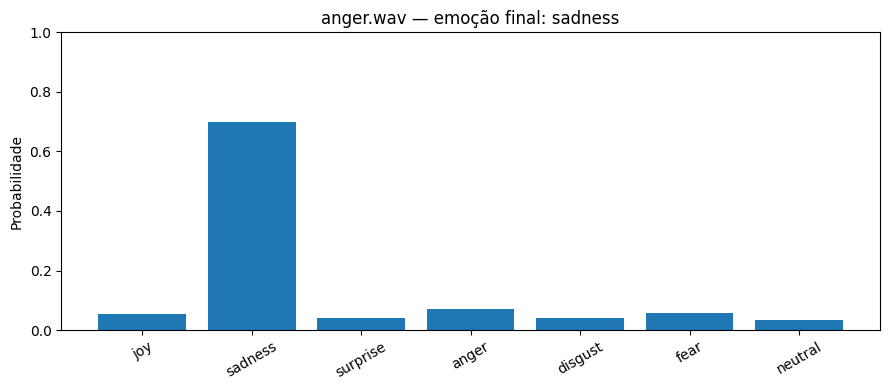

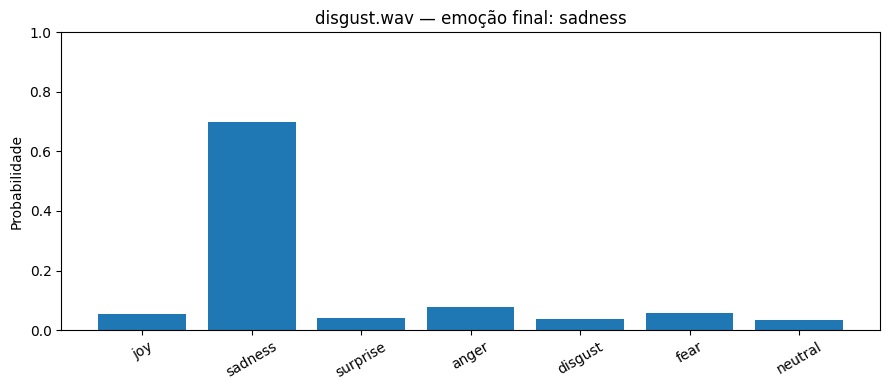

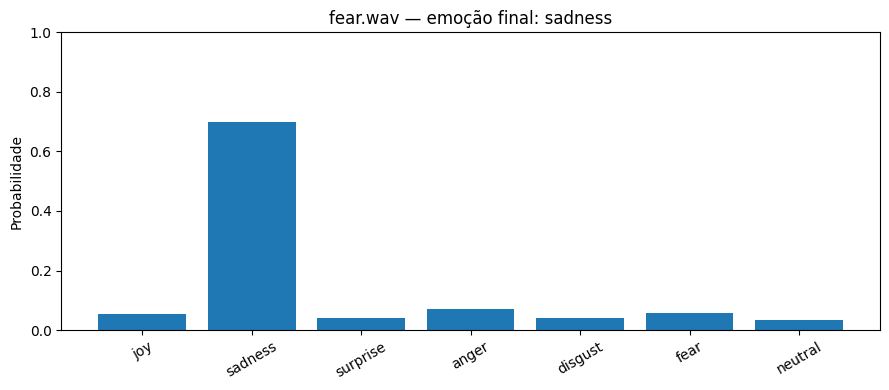

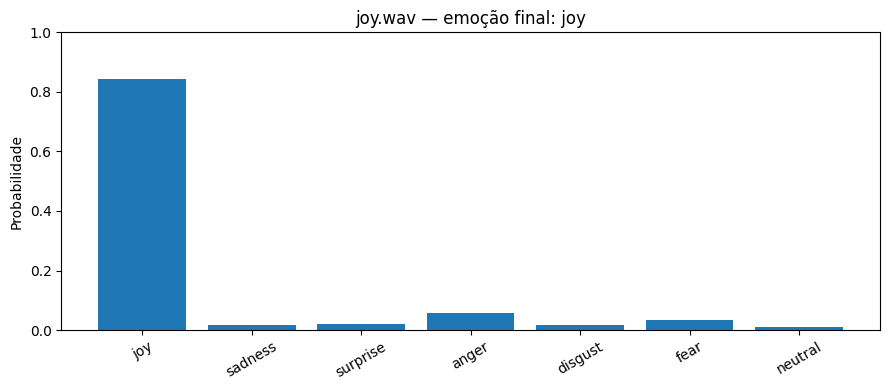

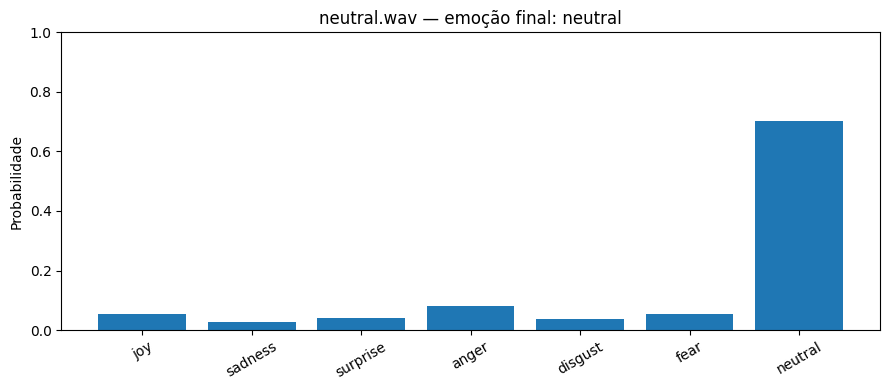

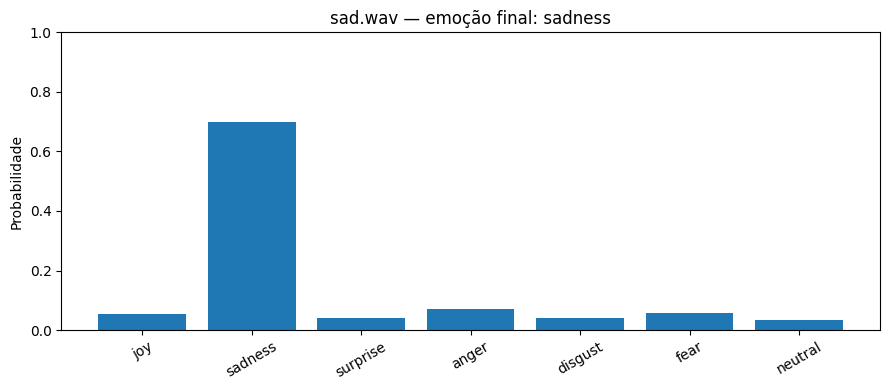

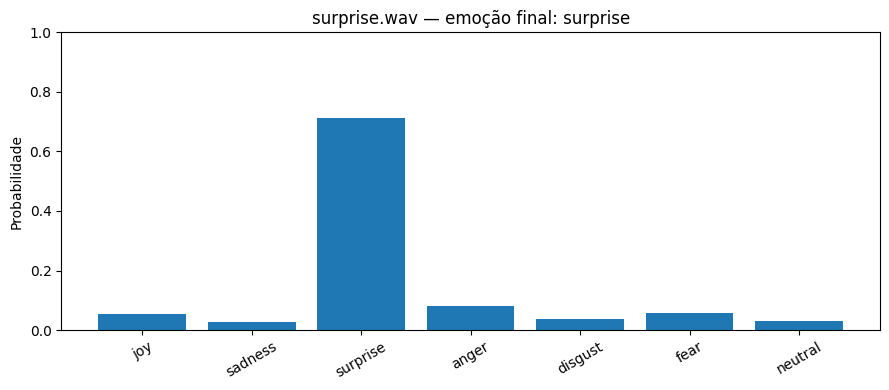

In [35]:
def plot_distribution(dist: Dict[str, float], title: str):
    labels = list(dist.keys())
    values = [dist[e] for e in labels]
    plt.figure(figsize=(9, 4))
    plt.bar(labels, values)
    plt.ylim(0, 1)
    plt.title(title)
    plt.ylabel("Probabilidade")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

if "all_results" in globals():
    for r in all_results:
        plot_distribution(r["final_distribution"], f"{r['file']} — emoção final: {r['final_emotion']}")

## 12. Scripts recomendados para gravação dos áudios

Usa estes textos como **teste controlado inicial**. O objetivo é verificar se a pipeline está funcional.

Depois, para validação mais realista, grava também relatos livres sem leres um texto preparado.

### `joy.wav`
Hoje foi um dia muito bom. Acordei com energia e senti que as coisas estavam finalmente a correr no caminho certo. Consegui terminar uma tarefa que já me estava a preocupar há algum tempo e isso deixou-me mesmo orgulhoso. Durante a tarde estive com pessoas de quem gosto e senti-me leve, bem-disposto e agradecido. Foi daqueles dias em que acabo com a sensação de que valeu a pena o esforço.

### `sad.wav` ou `sadness.wav`
Hoje foi um dia pesado. Acordei sem grande vontade de fazer nada e senti-me mais em baixo do que o habitual. Tive dificuldade em concentrar-me e várias coisas fizeram-me lembrar momentos menos bons. Mesmo quando tentei distrair-me, ficou sempre uma sensação de tristeza e cansaço emocional. Acabei o dia com vontade de ficar sozinho e descansar, porque senti que precisava de algum silêncio.

### `surprise.wav`
O meu dia começou de forma completamente normal, mas a meio da tarde aconteceu algo que eu não estava nada à espera. Recebi uma notícia que me apanhou desprevenido e fiquei durante algum tempo sem saber bem como reagir. Não foi propriamente mau, mas foi tão inesperado que passei o resto do dia a pensar nisso. Senti uma mistura de espanto, curiosidade e alguma agitação.

### `anger.wav`
Hoje fiquei bastante irritado. Houve uma situação em que senti que fui tratado de forma injusta e isso estragou-me o resto do dia. Tentei manter a calma, mas quanto mais pensava no assunto, mais frustrado ficava. Senti que o meu esforço não foi respeitado e isso deixou-me revoltado. No fim do dia ainda estava a tentar acalmar-me e esquecer o que aconteceu.

### `disgust.wav`
Hoje houve uma situação que me deixou mesmo incomodado. Vi uma atitude que achei profundamente desagradável e senti uma espécie de repulsa. Não foi só irritação, foi mesmo aquela sensação de querer afastar-me da situação e das pessoas envolvidas. Durante o resto do dia fiquei a pensar no quanto aquilo me pareceu errado e desconfortável. Foi um dia marcado por nojo e rejeição.

### `fear.wav`
Hoje passei o dia com bastante ansiedade. Desde manhã que estava preocupado com uma situação que podia correr mal e não consegui relaxar completamente. Mesmo quando tentava pensar noutra coisa, voltava sempre aquela sensação de insegurança. Senti o corpo tenso e a cabeça cheia de possibilidades negativas. Acabei o dia cansado, como se tivesse estado sempre em alerta.

### `neutral.wav`
Hoje foi um dia normal. Acordei, fiz as minhas tarefas habituais, trabalhei durante algumas horas e depois tratei de algumas coisas em casa. Não aconteceu nada de muito marcante, nem positivo nem negativo. Foi sobretudo um dia de rotina, com momentos simples e sem grandes alterações. Ao fim da tarde descansei um pouco e organizei o que tinha para fazer amanhã.

## 13. Como interpretar os resultados

- Se o **texto** acertar e a **prosódia** não, isso é normal: o texto é a modalidade mais forte no teu sistema.
- Se a **prosódia** acertar em emoções como `anger`, `neutral` ou `joy`, é um bom sinal, porque essas costumam ter pistas vocais mais claras.
- Se `fear`, `surprise` e `disgust` se confundirem, não é necessariamente erro grave; essas emoções são difíceis de distinguir só pela voz.
- Para o produto final, usa sempre a **distribuição final** e não apenas a classe dominante.

A etapa seguinte é copiares estas funções para o backend/frontend e substituíres os modelos antigos.